# kanly Quick-Start Guide

[<p align="center"><img src="images/kanly_logo_white_border.svg" width="300"></p>](images/kanly_logo.svg)

Runnable tour of core **kanly** workflows on one shared synthetic dataset. Run cells in order; each section prints summaries you can compare side by side.

**Topics covered**

- **Linear models** — OLS vs IV (2SLS), Shapley R² decomposition
- **GLM** — Poisson regression vs GLM-IV with residual inclusion (control-function IV)
- **Nonlinear least squares** — exponential mean model; IV-style control-function terms
- **Penalized regression** — LASSO variable selection and OLS refit on selected terms
- **Time Series Analysis** - [Sarimax](https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average) models 
- **Bayesian** — `DataModel` code blocks and a custom Numba `log_posterior` with AMH MCMC (Ray-parallel chains)
- **Bootstrap** — row vs block bootstrap on a linear model with within-cluster correlated errors
- **Nonparametrics** — KDE and LOWESS / Gaussian kernel smoothing

**How to read the output**

- Use `compare_results` tables to line up coefficients across specifications.
- In the endogeneity examples, focus on the `x` row: OLS is biased, IV and control-function approaches recover the target slope near **-0.4**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Synthetic data

We simulate `n = 5,000` rows with **intentional endogeneity** so later sections can show bias correction:

| Variable | Role |
|----------|------|
| `z` | Instrument: affects `x` but not in the outcome equation |
| `e` | Confounder: enters both `x` and `y` |
| `x` | Endogenous regressor: `x = 0.5·z + 0.6·e + noise` |
| `y` | Outcome: `log(y)` is linear in predictors with true `x` coefficient **-0.4** |
| `grp`, `grp2` | Categorical fixed effects for formula terms and LASSO |
| `x_proj`, `x_resid` | First-stage projection of `x` on `z` and residual (for NLLS control-function block) |

Because `x` and `y` both depend on `e`, a plain regression on `x` is **biased upward** (toward 0). The instrument `z` is valid for IV because it shifts `x` without appearing in the structural outcome.

In [ ]:
np.random.seed(0)
n = 5_000
z = np.random.randn(n)
e = np.random.randn(n)
x = .5 * z + .6 * e + .25 + np.random.randn(n)
grp = np.random.randint(0, 3, n)
grp2 = np.random.randint(0, 20, n)
y = np.exp(2 - 0.4 * x + .1 * (grp == 1) - .25 * (grp == 2) + .5 * (grp2 == 3) + 1.25 * e)

b1 = np.cov(z, x)[0, 1] / np.var(z)
b0 = x.mean() - b1 * z.mean()
x_proj = b0 + b1 * z
x_resid = x - x_proj

df = pd.DataFrame({
    'x': x, 'x_proj': x_proj, 'x_resid': x_resid,
    'grp': grp, 'grp2': grp2, 'y': y, 'z': z,
})
df.head()

,x,x_proj,x_resid,grp,grp2,y,z
0,1.115743,1.119594,-0.003851,0,3,11.482882,1.764052
1,-0.825626,0.441144,-1.266770,1,9,4.519630,0.400157
2,1.550817,0.728951,0.821867,1,1,0.643086,0.978738
3,1.223743,1.356792,-0.133049,0,0,2.242709,2.240893
4,0.046262,1.171081,-1.124819,1,16,1.085571,1.867558


## OLS and IV

#### Formula Interface

Fit the same log-linear specification with **HC1** standard errors:

- **OLS:** `log(y) ~ x + C(grp)`
- **IV (2SLS):** `log(y) ~ x + C(grp) | z + C(grp)` — `z` instruments endogenous `x`

The IV summary lists endogenous and excluded regressors. In `compare_results`, the `x` row is the key diagnostic: OLS is near **+0.07** (biased toward zero) while IV is near **-0.39**, close to the true **-0.4** used in the data-generating process.

In [ ]:
from kanly.api import lm, compare_results

fit_ols = lm('np.log(y) ~ x + C(grp)', df, cov_type='HC1', specification_name='OLS')
fit_iv = lm('np.log(y) ~ x + C(grp) | z + C(grp)', df, cov_type='HC1', specification_name='IV')

print(fit_ols)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Your version of `kanly` is 0.0.1045 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Your version of `kanly` is 0.0.1045 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

══════════════════════════════════════════════════════════════════════════
Linear Model Results
OLS
══════════════════════════════════════════════════════════════════════════

Dep. Variable:   I(np.log(y))

Date:                  Jun 03, 2026    No. Obs.                       5000
Time:                      10:11:08    Df Residuals:                  4996
Model Elapsed:               0.00 s    Df Model:                         3
Fit Elapsed:                 0.00 s    R-squared:                   0.0301
Cov Elapsed:                 0.02 s    Adj. R-squared:              0.0295
Method:                         OLS    F-statistic:                  51.15
L2 Penalty:                    None    Prob (F-statistic):           <.001
Weights:                

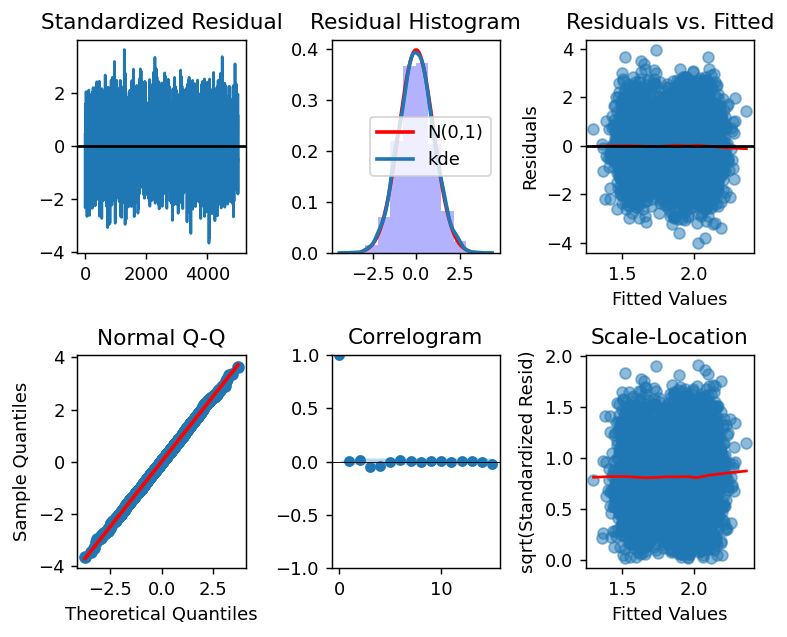

In [ ]:
plot = fit_ols.plot_diagnostics()

In [ ]:
print(fit_iv)

══════════════════════════════════════════════════════════════════════════
Linear Model Results
IV
══════════════════════════════════════════════════════════════════════════

Dep. Variable:   I(np.log(y))

Date:                  Jun 03, 2026    No. Obs.                       5000
Time:                      10:11:08    Df Residuals:                  4996
Model Elapsed:               0.01 s    Df Model:                         3
Fit Elapsed:                 0.00 s    R-squared:                  -0.2404
Cov Elapsed:                 0.00 s    Adj. R-squared:             -0.2411
Method:                   IV (2SLS)    F-statistic:                      -
L2 Penalty:                    None    Prob (F-statistic):               -
Weights:                          -    Log-Likelihood:                   -
Intercept:                     True    AIC:                              -
Implicit Intercept:           False    BIC:                              -
Covariance Type:                HC1    scale

In [ ]:
print(compare_results([fit_ols, fit_iv], show_bse=False, 
                      ref_param_values={'Intercept': 2, 'x': -.4}))


═════════════════════════════════════════════════════════════
Regression Summary Table
═════════════════════════════════════════════════════════════
                             (0)           (1)   |  Reference
─────────────────────────────────────────────────────────────
Intercept                  1.894         1.999   |      2.000
x                          0.068        -0.392   |     -0.400
C(grp)[1]                  0.123         0.130   |           
C(grp)[2]                 -0.289        -0.287   |           
═════════════════════════════════════════════════════════════
Model:                       LLS           LLS   |           
Outcome:            I(np.log(y))  I(np.log(y))   |           
No. Obs.                    5000          5000   |           
R-squared:                0.0301       -0.2404   |          -
R-squared Adj.:           0.0295       -0.2411   |           
Pseudo R-squared:                                |           
Method:                      OLS     IV (2SL

#### Array Interface

In [ ]:
from kanly.api import sparse_dmatrices, sparse_dmatrix, LM

y, X = sparse_dmatrices('np.log(y) ~ x + C(grp)', df)
y, X = y.values, X.values

Z = sparse_dmatrix('z + C(grp)', df).values

fit_iv_array = LM(y, X, instruments=Z)
fit_iv_array

══════════════════════════════════════════════════════════════════════════
Linear Model Results
══════════════════════════════════════════════════════════════════════════

Dep. Variable:   <y>

Date:                  Jun 03, 2026    No. Obs.                       5000
Time:                      10:11:09    Df Residuals:                  4996
Model Elapsed:               0.00 s    Df Model:                         3
Fit Elapsed:                 0.00 s    R-squared:                  -0.2404
Cov Elapsed:                 0.00 s    Adj. R-squared:             -0.2411
Method:                   IV (2SLS)    F-statistic:                      -
L2 Penalty:                    None    Prob (F-statistic):               -
Weights:                          -    Log-Likelihood:                   -
Intercept:                     True    AIC:                              -
Implicit Intercept:            True    BIC:                              -
Covariance Type:          OLS_SMALL    scale:           

### Shapley R² values

On the OLS fit, `fit_ols.shapley_value()` decomposes **R² by formula term** (here `x` vs `C(grp)`), not by individual dummy columns. This uses the fast quadratic-form path after a single `lm` fit — useful for understanding which terms drive explained variance without refitting every subset model from scratch.

In [ ]:
fit_ols.shapley_value(return_full=False)

,shapley_value,pct
C(grp),0.024072,0.801003
x,0.005980,0.198997


### Confidence Intervals

In [ ]:
print(fit_ols.conf_int(test_level=.1))

           [0.0500,   0.9500]
Intercept  1.849281  1.939107
x          0.047705  0.088855
C(grp)[1]  0.059972  0.185917
C(grp)[2] -0.351239 -0.226545


### Statistical Tests

In [ ]:
# Delta method
delta = fit_ols.test_delta_method('{x} / {Intercept}')

# From CLT
clt = fit_ols.test_from_clt_simulation('{x} / {Intercept}')

# Fieller
top = [1 if nm == 'x' else 0 for nm in fit_ols.param_names]
bottom = [1 if nm == 'Intercept' else 0 for nm in fit_ols.param_names]
fieller = fit_ols.test_ratio_fieller(top=top, bottom=bottom)

print(delta)
print(clt)
print(fieller)

{'estimate': 0.03604700995725634, 'ci_lo': 0.022995452008607767, 'ci_hi': 0.049098567905904916, 'pvalue': np.float64(6.190435957914827e-08), 'test_stat': 5.413211322706091, 'std_err': 0.006659080499232434}
{'estimate': np.float64(0.03604700995725634), 'ci_lo': np.float64(0.023099651327641902), 'ci_hi': np.float64(0.04917360288720448), 'pvalue': np.float64(0.0), 'std_err': np.float64(0.0066425878112008774), 'test_stat': None}
{'estimate': 0.03604700995725634, 'ci_lo': 0.023044612633185434, 'ci_hi': 0.049158376190052915, 'pvalue': np.float64(4.7696237153751275e-08), 'test_stat': 5.459691595855126, 'std_err': None}


## GLM and GLM-IV

Same endogeneity story on the **original scale** `y` (Poisson GLM, not log-transformed):

- **GLM:** `y ~ x + C(grp)`
- **GLM-IV with residual inclusion:** `y ~ x + C(grp) | z + C(grp)`, `residual_inclusion=True`, `residual_inclusion_order=3`

For nonlinear models, naive IV (substituting fitted endogenous regressors without residuals) is generally inconsistent. **Residual inclusion** appends powers of the first-stage residual on `x`; the extra `x_r(1)`, `x_r(2)`, … rows in the table are those control-function terms. Compare the `x` coefficient: GLM is biased positive; GLM-IV moves toward the true **-0.4**.

In [ ]:
from kanly.api import glm

fit_glm = glm('y ~ x + C(grp)', df, family='poisson', specification_name='GLM')
fit_glm_iv = glm(
    'y ~ x + C(grp) | z + C(grp)', df, family='poisson',
    specification_name='GLM-IV',
    residual_inclusion=True,
    residual_inclusion_order=3,
)
print(fit_glm_iv)

═══════════════════════════════════════════════════════════════════════════
Generalized Linear Model Results
GLM-IV
═══════════════════════════════════════════════════════════════════════════

Dep. Variable: y

Date:              Jun 03, 2026    Deviance:            6.6908e+04
Time:                  10:11:09    Pearson chi2:       116721.6409
Family:                 POISSON    Scale:               1.0000e+00
Link:                       LOG    Converged:                 True
Var Weights:                  -    Iterations:                   6
Method:                    IRLS    Rel. Err.:             5.67e-08
Nobs:                      5000    Abs. Err.:             7.99e-15
Df Residuals:              4993    Cov. Type:            NONROBUST
Df Model:                     7    Model Elapsed:            0.01s
Log-Likelihood:     -4.2801e+04    Fit Elapsed:              0.01s
Pseudo Rsq:              0.0631    Cov Elapsed:              0.00s

═══════════════════════════════════════════════════

In [ ]:
print(compare_results([fit_glm, fit_glm_iv], show_bse=False, ref_param_values={'x': -.4}))


════════════════════════════════════════════════════════════
Regression Summary Table
════════════════════════════════════════════════════════════
                          (0)        (1)   |  Reference
────────────────────────────────────────────────────────────
Intercept               2.506      2.570   |           
x                       0.072     -0.391   |     -0.400
C(grp)[1]               0.105      0.113   |           
C(grp)[2]              -0.306     -0.302   |           
x_r(1)                             0.159   |           
x_r(2)                             0.008   |           
x_r(3)                            -0.002   |           
════════════════════════════════════════════════════════════
Model:                    GLM        GLM   |           
Outcome:                    y          y   |           
No. Obs.                 5000       5000   |           
R-squared:                                 |          -
R-squared Adj.:                            |           
Ps

## Nonlinear least squares (NLLS)

Nonlinear mean on the **original scale** of `y` (not log-transformed). NLLS uses its own formula syntax — **not** the same as `lm` / `glm` (`y ~ x + C(grp)`).

### NLLS formula syntax (quick reference)

```text
[y] ~ <prediction>  $  [weights]     # weights optional
```

| Token | Meaning | Example in this section |
|-------|---------|-------------------------|
| **`[...]`** | Data from `df` — columns or expressions, evaluated when the model is built | `[x]`, `[x_proj]`, `[x_resid**2]`, `[C(grp,-1)]` |
| **`{...}`** | **Parameters to estimate** — each name becomes one (or more) coefficients in the optimizer | `{Intercept}`, `{x}`, `{x_resid}`, `{x_resid2}` |
| **`$ [w]`** | Optional observation weights (not used here) | — |

The **right-hand side** is the predicted mean `ŷᵢ = f(dataᵢ, β)` and may be **nonlinear in `{parameters}`** — here `np.exp(...)`. Use NumPy callables (`np.exp`, etc.) freely.

**Categorical terms:** write fixed effects inside brackets, e.g. `[C(grp,-1)]` (reference category −1), analogous to patsy but bracketed.

**Bracket placement:** `np.exp({Intercept} + {x}*[x])` applies `exp` each residual evaluation; `[np.exp(x)]` would precompute once. Here the exponential wraps parameters, so it stays outside the data brackets.

### Models fit below

- **NLLS:** `[y] ~ np.exp({Intercept} + {x}·[x] + [C(grp,-1)])`
- **NLLS-IV (control-function style):** replaces `{x}·[x]` with `{x}·[x_proj]` and adds `{x_resid}·[x_resid]` and `{x_resid2}·[x_resid**2]` from the first-stage projection of `x` on `z`

The naive NLLS coefficient on `x` is small and positive (similar to biased GLM/OLS). The IV-style specification pulls `x` toward **−0.38**, in line with the true effect. Standard errors on the IV-style fit are not reliable for inference because `x_proj` and `x_resid` were built from the same sample used in estimation.

In [ ]:
from kanly.api import nlls

fit_nlls = nlls(
    '[y] ~ np.exp({Intercept} + {x}*[x] + [C(grp,-1)])',
    df,
    specification_name='NLLS',
)
fit_nlls_iv = nlls(
    '[y] ~ np.exp({Intercept} + {x}*[x_proj] + {x_resid}*[x_resid] + {x_resid2}*[x_resid**2] + [C(grp,-1)])',
    df,
    specification_name='NLLS-IV',
)

print(fit_nlls)

══════════════════════════════════════════════════════════════════════════
Nonlinear Least Squares Results
NLLS
══════════════════════════════════════════════════════════════════════════

Dep. Variable: y

Date:                  Jun 03, 2026    R-squared:                   0.0165
Time:                      10:11:09    Adj. R-squared:              0.0159
Weights:                       None    Model Time:                   0.00s
Nobs:                          5000    Fit Time:                     0.25s
Df Residuals:                  4996    Cov Time:                     0.00s
Df Model:                         4    Iterations:                       9
Cost:                    7.6388e+05    Converged:                     True
Scale:                   3.0580e+02    Status:                           2
LLF:                    -2.1400e+04    Covariance Type:          OLS_SMALL
Penalty:                 0.0000e+00    Active Constraints:               0
Objective:               7.6388e+05    Metho

In [ ]:
print(compare_results([fit_nlls, fit_nlls_iv], show_bse=False, ref_param_values={'x': -.4}))


════════════════════════════════════════════════════════════
Regression Summary Table
════════════════════════════════════════════════════════════
                          (0)        (1)   |  Reference
────────────────────────────────────────────────────────────
Intercept               2.506      2.574   |           
x                       0.075     -0.381   |     -0.400
C(grp)[1]               0.103      0.114   |           
C(grp)[2]              -0.310     -0.325   |           
x_resid                            0.155   |           
x_resid2                           0.006   |           
════════════════════════════════════════════════════════════
Model:                   NLLS       NLLS   |           
Outcome:                    y          y   |           
No. Obs.                 5000       5000   |           
R-squared:             0.0165     0.0468   |          -
R-squared Adj.:        0.0159     0.0459   |           
Pseudo R-squared:                          |           
Me

## Penalized regression (LASSO)

Elastic net with `l1_ratio=1` (pure LASSO) on `log(y) ~ x + C(grp) + C(grp2)` — many `grp2` levels, so sparsity is useful. The summary shows only **non-zero** coefficients (most `grp2` dummies are zeroed out).

With `refit=True`, kanly returns a second fit: OLS on the **selected** support only, giving classical inference on the retained terms. The following cell compares OLS, LASSO-only coefficients, and LASSO+refit OLS.

The example here is LASSO, but you can easily do ridge and elastic-net by varying `l1_ratio`.

In [ ]:
from kanly.api import elastic_net

fit_penalized = elastic_net(
    'np.log(y) ~ x + C(grp) + C(grp2)',
    df,
    alpha=0.001,
    l1_ratio=1.0,
    normalize=True,
    fit_intercept=True,
    specification_name='Lasso',
)
print(fit_penalized.summary(show_only_non_zero=True, show_formula=False))

════════════════════════════════════════════════════════════════
Penalized Linear Model Results
Lasso
════════════════════════════════════════════════════════════════

Dep. Variable: I(np.log(y))

Date:             Jun 03, 2026    |dx|:                 3.59e-06
Time:                 10:11:09    |dF/F|                1.10e-11
Method:                  LASSO    max|subgrad|:         2.30e-07
Nobs:                     5000    alpha:                1.00e-03
Params:                     25    l1_ratio:             1.00e+00
Score:                  0.0266    fit_intercept:            True
SSR:                6.0134e+03    normalize:                True
Penalty:            1.0997e-02    positive:                False
Objective:          6.1233e-01    scaled:                  False
Weights:                     -    relaxation:                   
Converged:                True    active_set:               True
Iters:                      16    selection:              random
Max Iter:              

### LASSO with OLS refit

The `elastic_net(..., refit=True)` call returns `(lasso_fit, ols_on_selected)`. The comparison table below contrasts three coefficient vectors on overlapping terms.

In [ ]:
fit_penalized_refit = elastic_net(
    'np.log(y) ~ x + C(grp) + C(grp2)',
    df,
    alpha=0.001,
    l1_ratio=1.0,
    normalize=True,
    fit_intercept=True,
    specification_name='Lasso w/Refit',
    refit=True
)
print(fit_penalized_refit[1])

══════════════════════════════════════════════════════════════════════════
Linear Model Results
Lasso w/Refit
══════════════════════════════════════════════════════════════════════════

Dep. Variable:   I(np.log(y))

Date:                  Jun 03, 2026    No. Obs.                       5000
Time:                      10:11:09    Df Residuals:                  4995
Model Elapsed:               0.00 s    Df Model:                         4
Fit Elapsed:                 0.00 s    R-squared:                   0.0399
Cov Elapsed:                 0.00 s    Adj. R-squared:              0.0392
Method:                         OLS    F-statistic:                  51.94
L2 Penalty:                    None    Prob (F-statistic):           <.001
Weights:                          -    Log-Likelihood:          -7521.6853
Intercept:                     True    AIC:                       15053.37
Implicit Intercept:            True    BIC:                       15085.96
Covariance Type:          OLS_SMA

In [ ]:
print(compare_results([fit_ols, fit_penalized, fit_penalized_refit[1]], 
                      show_bse=False, show_formulas=False, ))


════════════════════════════════════════════════════════════
Regression Summary Table
════════════════════════════════════════════════════════════
                             (0)           (1)           (2)
────────────────────────────────────────────────────────────
Intercept                  1.894         1.897         1.869
x                          0.068         0.012         0.067
C(grp)[1]                  0.123         0.023         0.122
C(grp)[2]                 -0.289        -0.188        -0.289
C(grp)[0]                            0.000e+00              
C(grp2)[0]                           0.000e+00              
C(grp2)[1]                           0.000e+00              
C(grp2)[2]                           0.000e+00              
C(grp2)[3]                               0.185         0.494
C(grp2)[4]                           0.000e+00              
C(grp2)[5]                           0.000e+00              
C(grp2)[6]                           0.000e+00             

### Quantile Regression

In [ ]:
from kanly.api import qr

tau = .95
fit_qr = qr('np.log(y) ~ x', df, tau=.95)
fit_mean = lm('np.log(y) ~ x', df)

fit_qr


════════════════════════════════════════════════════════════════════
Quantile Regression Results
════════════════════════════════════════════════════════════════════

Dep. Variable: I(np.log(y))

Date:               Jun 03, 2026    No. Obs.                    5000
Time:                   10:11:09    Df Residuals:               4998
Model Elapsed:            0.01 s    Df Model:                      1
Fit Elapsed:              0.01 s    Converged:                  True
Cov Elapsed:              0.00 s    Iterations:                   10
Quantile:                   0.95    Error:                  3.50e-08
Pseudo-rsquared:          0.0042    Cost:                 2.8731e+02
Method:                     IRLS    True Cost:            2.8731e+02
Covariance Type:             IID    Line Search:                True

══════════════════
              coef
──────────────────
Intercept    3.687
x          0.07202
══════════════════

formula:  np.log(y) ~ x

Converged: relative change in cost 2.27e-1

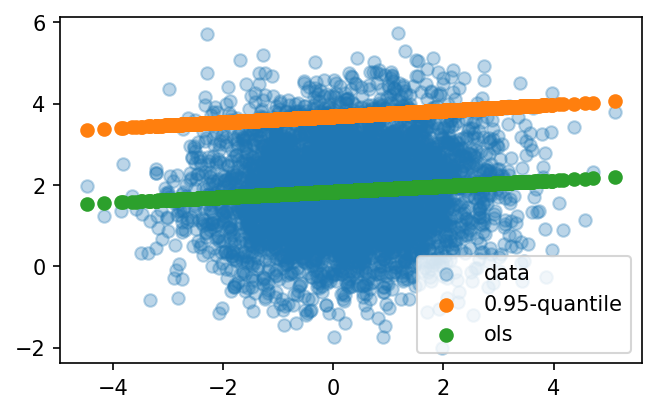

In [ ]:
plt.figure(dpi=150, figsize=(5,3))
plt.scatter(df.x, np.log(df.y), alpha=.3, label='data')
plt.scatter(df.x, fit_qr.fittedvalues, label=f'{tau}-quantile')
plt.scatter(df.x, fit_mean.fittedvalues, label=f'ols')
plt.legend(loc='best')

## Time Series Estimation (SARIMAX)

We simulate a short series (`n = 100`) and fit a **SARIMAX** model with exogenous regressors using the formula interface (`sarimax`).

**Data-generating process**

1. Draw **innovations** `e` from an **ARIMA(2, 1, 1)** process via `simulate_sarima`:
   - AR coefficients: **0.6**, **0.1**
   - MA coefficient: **−0.2**
   - One difference (`d = 1`), innovation variance **σ² = 1.6**
2. Draw independent exogenous series `x` and `w`.
3. Build the outcome: **`y = 0.15·x − 0.25·w + e`**.

**Model fit**

```python
sarimax('y ~ x + w', df, order=(2, 1, 1))
```

This specifies an **ARIMAX(2, 1, 1)** for `y` with regressors `x` and `w` (no separate deterministic trend—the `-1` in the printed formula means no intercept). Maximum likelihood uses the Brockwell & Davis state-space / Kalman filter implementation.

**How to read the answer**

| Quantity | True (simulation) | Estimated (typical) | Takeaway |
|----------|-------------------|---------------------|----------|
| `x` coef | 0.15 | ~0.14 | Exogenous effect recovered reasonably well |
| `w` coef | −0.25 | ~−0.15 | Same sign; imprecise with only 100 points |
| `ar.L1`, `ar.L2` | 0.6, 0.1 | ~0.56, ~0.05 | In the right ballpark |
| `ma.L1` | −0.2 | ~−0.21 | Close to the truth |
| `sigma2` | 1.6 | ~1.60 | Well estimated (often highly significant) |
| R² | — | ~0.99 | In-sample `predict()` tracks `y` closely (see plot below) |

With **100 observations**, standard errors on the AR/MA parameters are large, so those terms are usually **not** individually significant even when the true process is ARIMA(2, 1, 1)—that is a sample-size issue, not necessarily misspecification. The exogenous slopes and `sigma2` are the most interpretable rows here.

**Diagnostics in the summary**

- **`converged: True`** and small **`max|grad|`** — the optimizer found a sensible optimum.
- **Ljung–Box Q ≈ 0**, **Prob(Q) ≈ 1** — no evidence of leftover autocorrelation in the first lag of residuals (what you want after a reasonable ARIMA fit).
- **Durbin–Watson ≈ 2** — consistent with uncorrelated residuals at lag 1.

The next cell overlays **`fit_sarima.predict()`** on the simulated `y`; the high R² reflects that both the exogenous part and the ARIMA structure are doing work in-sample.

In [ ]:
from kanly.api import simulate_sarima, sarimax

n = 100
np.random.seed(0)
e = simulate_sarima(
    n=n,
    ar=[0.6, .1],
    ma=[-.2],
    d=1,
    sigma2=1.6,
    seed=0,
    burnin=1000,
)
x = np.random.randn(n)
w = np.random.randn(n)
y = .15 * x - .25 * w + e

df_time_series = pd.DataFrame({'y': y, 'x': x, 'w': w})

fit_sarima = sarimax('y ~ x + w', df_time_series, order=(2,1,1))
print(fit_sarima)

══════════════════════════════════════════════════════════════════════════
SARIMAX Model Results
══════════════════════════════════════════════════════════════════════════

Dep. Variable: y

Model:               SARIMAX(2,1,1)    Log Likelihood:           -163.9481
                                       Avg. LL:                    -1.6560
Date:                  Jun 03, 2026    AIC:                        339.896
Time:                      10:11:10    AICc:                       340.819
model time:                   0.00s    BIC:                        355.406
fit time:                     0.04s    HQIC:                       346.170
cov time:                     0.00s    R-squared:                   0.9881
Covariance Type:                opg    Adj. R-squared:              0.9875
No. Observations:               100    converged:                     True
Likelihood Burn:                  1    max|grad|:                 5.81e-05
df Model:                         6    iter:               

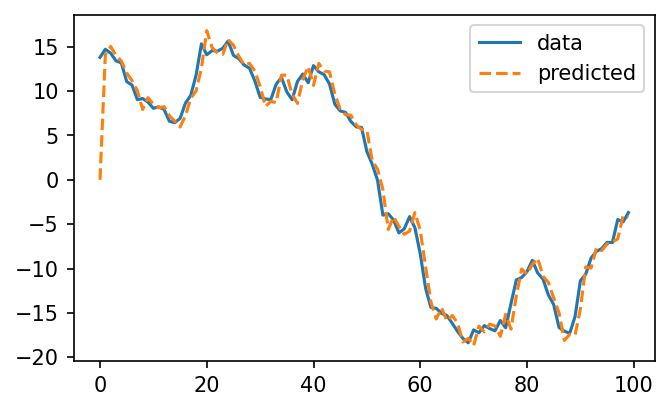

In [ ]:
plt.figure(figsize=(5, 3), dpi=150)
plt.plot(y, label='data')
plt.plot(fit_sarima.predict(), label='predicted', ls='--')
plt.legend(loc='best')
plt.show()

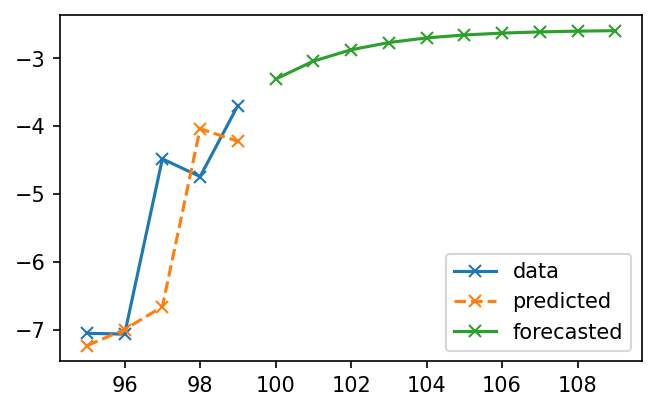

In [ ]:
# forecasting
plt.figure(figsize=(5, 3), dpi=150)
plt.plot(range(len(y)-5,len(y)), y[-5:], label='data', marker='x')
plt.plot(range(len(y)-5,len(y)), fit_sarima.predict()[-5:], label='predicted', marker='x', ls='--')
exog = np.tile(df_time_series[['x', 'w']].mean(), 10).reshape((-1,2))
plt.plot(range(len(y),len(y)+10), fit_sarima.get_forecast(steps=10, exog=exog), marker='x', label='forecasted')
plt.legend(loc='best')
plt.show()

## Bayesian estimation

Two ways to specify a **Normal regression on `log(y)`** with a **strong prior on the slope of `x`**. Both call the same underlying sampler: **AMH MCMC** (adaptive Metropolis–Hastings with Langevin proposals), with **4 chains in parallel via Ray** when available.

**Shared statistical setup (this example)**

- Likelihood: `log(y) ~ Normal(μ, σ)` with `μ = Intercept + β_x·x + …` (plus group effects in the first example).
- Prior on `x`: **Normal(−1, 0.01²)** — very tight around −1 (not centered on the structural −0.4 from the DGP, deliberately, to show prior pull).
- Starting values passed to `.sample({...})` seed each chain; defaults otherwise use AMH’s adaptive proposal tuning.

**What to look for in the printed summary**

- **`R_hat` ≈ 1** and **`R_hat > 1.01: 0/k`** — chains agree (Gelman–Rubin).
- **`ESS`** — effective sample size per parameter; higher is better (note if below 5000).
- **Posterior mean of `x`** — here ~**−0.72**, between the prior mean (−1) and the OLS-ish likelihood (~+0.07); the tight prior dominates less than you might expect because the data still pull the slope negative.
- **`sigma`** — posterior ~**1.47**, the residual scale on the log scale.

---

### `DataModel` (code-block DSL)

String **data** and **model** blocks compile to Numba-optimized code (STAN-like workflow, but Python-native).

| Block | Role in this cell |
|-------|-------------------|
| **`data_code_block`** | Loads columns: `` `x` ``, `` `np.log(y)` ``, `` `C(grp)` `` (formula-style categoricals). |
| **`model_code_block`** | Returns the **sum of log-densities**: Normal(`log_y`, mean, `sigma`). Mean = `$Intercept$ + $x$·x + $_dummy[grp,-1]$` (reference category −1 for `grp`). |
| **`priors={'x': 'norm(-1,.01)'}`** | Declarative prior on `x` only; other parameters get implicit/default handling unless specified. |

`build_data_model(..., data=df).to_bayesian_model(priors=...)` produces a `BayesianModel` under the hood. `.sample({'sigma': 1.0, 'x': 10})` runs MCMC with those starting values for the named parameters.

**Output:** five parameters — `Intercept`, `x`, two `C(grp)` contrasts, and `sigma`. Compare the `x` row to the earlier OLS/IV tables on the same `df`.

In [ ]:
from kanly.api import build_data_model

model = build_data_model(
    data_code_block='''
    self.x = `x`
    self.y = `y`
    self.log_y = `np.log(y)`
    self.grp = `C(grp)`
    self.grp2 = `C(grp2)`
    ''',
    model_code_block='''
    return logpdf_norm(log_y, $Intercept$ + $x$ * x + $_dummy[grp,-1]$, $sigma<0,np.inf>$).sum()
    ''',
    data=df,
).to_bayesian_model(priors={'x': 'norm(-1,.01)'})

fit_mcmc_data_model = model.sample({'sigma': 1.0, 'x': 10})
print(fit_mcmc_data_model)

2026-06-03 10:11:14,084	INFO worker.py:2012 -- Started a local Ray instance.


═════════════════════════════════════════════════════════════════════════════════════════════
MCMC Results
─────────────────────────────────────────────────────────────────────────────────────────────

Num Parameters:     5
Method:             AMH

Date:                Jun 03, 2026        Acceptance Rate:                0.2374
Time:                    10:11:19        Adaptive:                         True
                                                                               
Total Iterations:          120000        Efficiency:                           
MCMC Draw Time:             7.85s            Min:                        0.0558
R_hat Time:                 0.00s            Avg:                        0.0582
ESS Time:                   0.02s            Max:                        0.0604
Summary Time:               0.18s                                              
                                         Gelman-Rubin:                         
No. Chains:                    

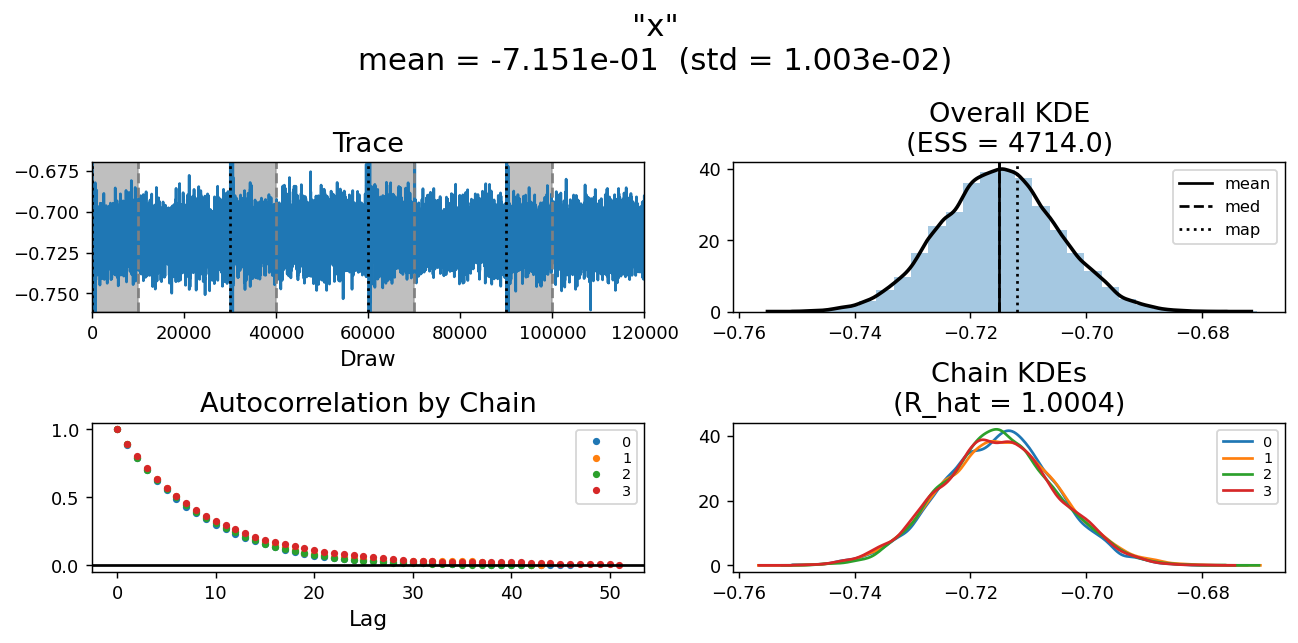

In [ ]:
diag_plot = fit_mcmc_data_model.diagnostic_plot('x', show=False)

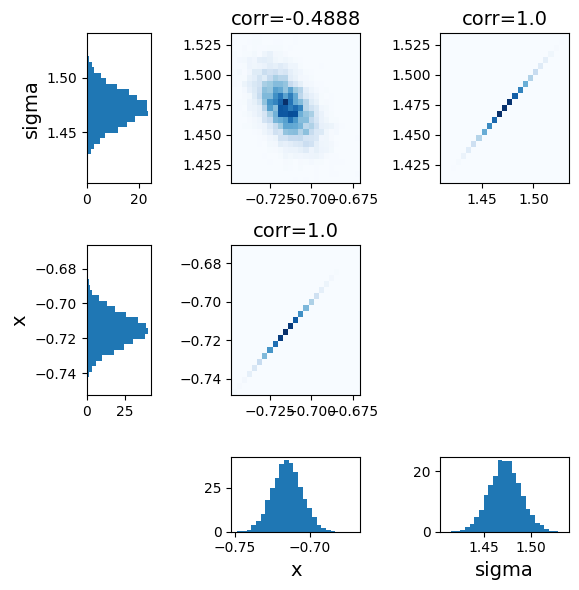

In [ ]:
plot2 = fit_mcmc_data_model.multi_scatter(['x', 'sigma'], figsize=(6,6))

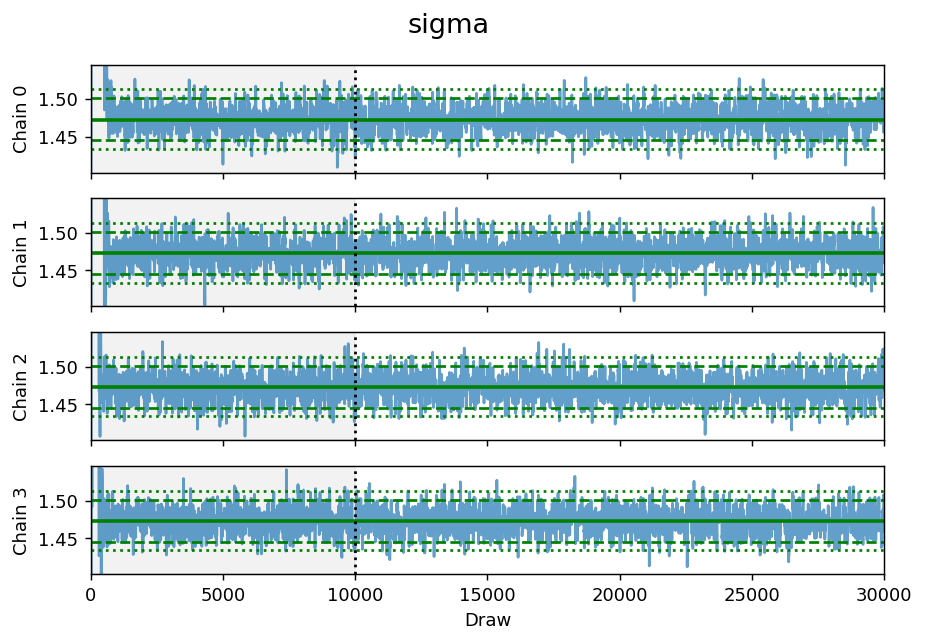

In [ ]:
plot3 = fit_mcmc_data_model.trace('sigma', show=False, figsize=(7,5))

### `BayesianModel` (custom log-posterior)

Same **log-scale Normal likelihood** and **`x ~ Normal(−1, 0.01)` prior**, but written explicitly in a single **`@njit` function** that returns **log-likelihood + log-prior** (kanly treats this as the log-posterior up to a constant).

| Piece | Role in this cell |
|-------|-------------------|
| **`log_posterior(params)`** | `params = [Intercept, x, sigma]`; sums `logpdf_norm(log(y), …)` over rows and adds the prior on `x`. |
| **`BayesianModel(..., bounds={'sigma': [0, np.inf]})`** | Enforces **σ > 0** during sampling (not needed in the string DSL when you write `$sigma<0,np.inf>$`). |
| **`param_names`** | Labels for the summary table. |
| **`.sample({'sigma': 1})`** | Only `sigma` is given a custom start; other coordinates use defaults. |

This is a **deliberately simpler** mean structure — **no `C(grp)` fixed effects** — so you get **3 parameters** instead of 5 and a faster run (~6s vs ~10s). The posterior for `x` is still ~**−0.72** with **`R_hat ≈ 1`**, similar to the full `DataModel` fit.

**When to use which**

- **`DataModel`** — large models, many parameters, formula-like data prep, priors as strings; best when you want readable model specs without hand-rolling Numba.
- **`BayesianModel` + `@njit`** — custom densities, constraints, or logic that does not map cleanly to code blocks; full control over the log-posterior in Python/Numba.

In [ ]:
from numba import njit
from kanly.api import logpdf_norm, BayesianModel

x, y = df.x.values, df.y.values

@njit
def log_posterior(params):
    intercept = params[0]
    x_coef = params[1]
    sigma = params[2]
    return (
        logpdf_norm(np.log(y), intercept + x_coef * x, sigma).sum()
        + logpdf_norm(x_coef, -1, .01)
    )

model = BayesianModel(
    log_likelihood_function=log_posterior,
    bounds={'sigma': [0, np.inf]},
    param_names=['Intercept', 'x', 'sigma'],
)
fit_mcmc_functional = model.sample({'sigma': 1})
print(fit_mcmc_functional)

2026-06-03 10:11:22,608	INFO worker.py:2012 -- Started a local Ray instance.


══════════════════════════════════════════════════════════════════════════════════════════════
MCMC Results
──────────────────────────────────────────────────────────────────────────────────────────────

Num Parameters:     3
Method:             AMH

Date:                Jun 03, 2026        Acceptance Rate:                0.2386
Time:                    10:11:27        Adaptive:                         True
                                                                               
Total Iterations:          120000        Efficiency:                           
MCMC Draw Time:             6.65s            Min:                        0.0869
R_hat Time:                 0.00s            Avg:                        0.0904
ESS Time:                   0.01s            Max:                        0.0940
Summary Time:               0.25s                                              
                                         Gelman-Rubin:                         
No. Chains:                  

## Bootstrapping

This section uses a **separate** dataset (not the main `df`) with **25 clusters** (`grp`) and **within-block correlation** in the errors:

- Each observation gets a cluster label `grp` and a covariate `x` that varies by cluster.
- For each cluster `g`, errors are drawn as a **group intercept** plus a multivariate normal vector with covariance `I + 0.2·(11ᵀ − I)`: observations in the same block share correlation **0.2** (plus a common cluster shock).
- The outcome is linear: `y = 1.5 + 0.35·x + e`.

We then fit `y ~ x + C(grp)` four ways and compare inference on `x`:

| Specification | Inference | Resampling unit |
|---------------|-----------|-----------------|
| `hc1` | Huber–White, treats rows as independent | — |
| `cluster` | Cluster-robust sandwich on `grp` | — |
| `bootstrap` | 1,000 **row** bootstrap replications | rows |
| `block-bootstrap` | 1,000 **block** bootstrap replications (`groups='grp'`) | clusters |

**Block bootstrap** resamples whole clusters (with replacement), then refits on the stacked sample—appropriate when errors are correlated within `grp`. **Row bootstrap** ignores that structure and typically understates uncertainty here.

In `compare_results(..., show_t=True)`, the **t critical value** column differs by method: for block bootstrap, kanly sets the t-distribution **degrees of freedom to the number of clusters minus one** (`num_groups − 1 = 24` here), not `n − k`. Row bootstrap uses the model’s residual df (`n − k`). Check the printed `df` dict at the bottom of the comparison table.

In [ ]:
np.random.seed(0)
n = 500
num_groups = 25
grp = np.random.randint(0,num_groups,n)
x = np.random.randn(n) + .6 * grp
e = np.zeros(n)
for g in range(num_groups):
    idx = grp==g
    n_g = np.count_nonzero(idx)
    cov = np.eye(n_g) + (np.ones((n_g,n_g))-np.eye(n_g)) * .2
    e[idx] = np.random.randn() + np.random.multivariate_normal(np.zeros(n_g), cov)       
y = 1.5 + .35 * x + e 
df_boot = pd.DataFrame({'y': y, 'grp': grp, 'x': x})

In [ ]:
from kanly.api import lm, compare_results


fits = (
    lm('y ~ x + C(grp)', df_boot, cov_type='hc1', specification_name='hc1'),
    lm('y ~ x + C(grp)', df_boot, cov_type='cluster',
       cov_kwds={'groups': 'grp'},
       specification_name='cluster'),
    lm('y ~ x + C(grp)', df_boot, cov_type='bootstrap', 
       cov_kwds={'n_samples': 1_000},
       specification_name='bootstrap'),
    lm('y ~ x + C(grp)', df_boot, cov_type='bootstrap', 
       cov_kwds={'n_samples': 1_000, 'groups': 'grp'}, specification_name='block-bootstrap'),
)

print(compare_results(fits, show_t=True))

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv2/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv2/lib/python3.13/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv2/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv2/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/base_events.py", line 683, in run_forever
    self._run_once()
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/base_events


══════════════════════════════════════════════════════════════════
Regression Summary Table
══════════════════════════════════════════════════════════════════
                          (0)          (1)        (2)          (3)
──────────────────────────────────────────────────────────────────
Intercept               5.095        5.095      5.095        5.095
                      (0.185)      (0.008)    (0.181)      (0.007)
                     t=27.470    t=671.334   t=28.136    t=705.209


x                       0.306        0.306      0.306        0.306
                      (0.039)      (0.036)    (0.038)      (0.034)
                      t=7.814      t=8.619    t=8.144      t=9.054


C(grp)[1]              -2.759       -2.759     -2.759       -2.759
                      (0.243)      (0.002)    (0.234)      (0.002)
                    t=-11.377  t=-1206.098  t=-11.815  t=-1266.956


C(grp)[2]              -5.317       -5.317     -5.317       -5.317
                      (0.265) 

In [ ]:
{f.specification_name: f.df_t_dist for f in fits}

{'hc1': 474, 'cluster': 24, 'bootstrap': 474, 'block-bootstrap': 24}

## Nonparametrics

Brief visualization of **kanly.nonparametric** tools on synthetic samples (independent of the regression examples above).

### Kernel density estimation (`kde`)

A mixture of three normals is histogrammed; `kde` overlays two bandwidths (`adjust=0.3` vs `adjust=1.0`). The FFT-based KDE path is fast on large `n`.

Text(0.5, 1.0, 'kde')

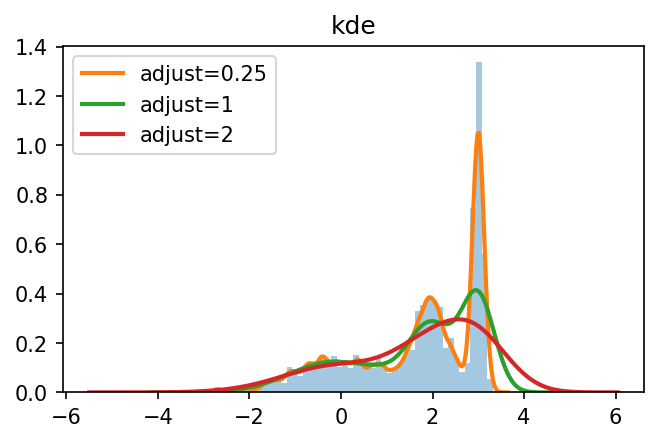

In [ ]:
np.random.seed(0)
x = np.hstack([np.random.randn(500), 2+.4*np.random.randn(500),3+.1*np.random.randn(500)])

plt.figure(dpi=150, figsize=(5,3))
plt.hist(x, density=True, alpha=.4, bins=50)

from kanly.api import kde
plt.plot(*kde(x, return_arrays=True, adjust=0.25), lw=2, label=f'adjust={.25}')
plt.plot(*kde(x, return_arrays=True, adjust=1.0), lw=2, label=f'adjust={1}')
plt.plot(*kde(x, return_arrays=True, adjust=2.0), lw=2, label=f'adjust={2}')
plt.legend(loc='best')
plt.title('kde')

### LOWESS and Gaussian kernel smoothing

On a noisy sinusoid plus trend: **LOWESS** at two fractions (`frac=0.25` and `0.05`) and **Gaussian kernel smoothing** (`gaussian_kernel_smooth`) for local smoothing without a parametric mean form.

Text(0.5, 1.0, 'lowess')

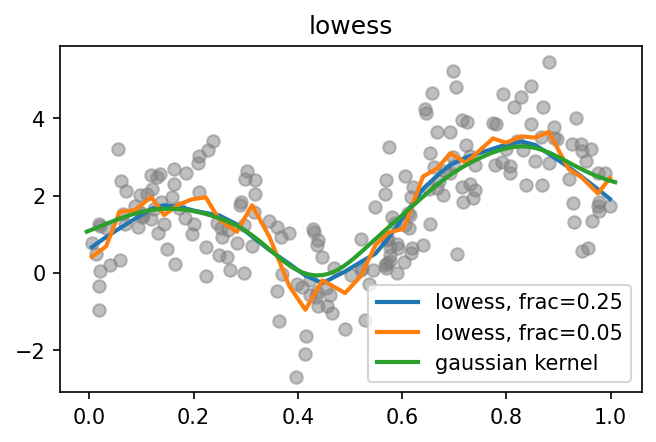

In [ ]:
np.random.seed(0)
n = 200
x = np.random.rand(n)
y = 1.5*np.sin(10*x) + 3*x + np.random.randn(n)

plt.figure(dpi=150, figsize=(5,3))
plt.scatter(x, y, alpha=.5,c='grey')

from kanly.api import LOWESS, gaussian_kernel_smooth
plt.plot(*LOWESS(y, x, return_arrays=True, degree=1, it=0, frac=.25), lw=2, label=f'lowess, frac={.25}')
plt.plot(*LOWESS(y, x, return_arrays=True, degree=1, it=0, frac=.05), lw=2, label=f'lowess, frac={.05}')
plt.plot(*gaussian_kernel_smooth(x, y, return_arrays=True, adjust=.5), lw=2, label=f'gaussian kernel')
plt.legend(loc='best')
plt.title('lowess')

### Interpolation

Text(0.5, 1.0, 'interpolation')

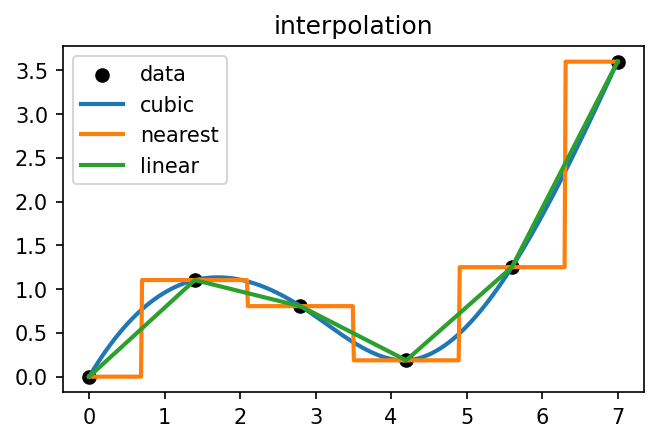

In [ ]:
from kanly.api import interp

x = np.linspace(0,7,6)
y = np.sin(x) + .06 * x ** 2

plt.figure(figsize=(5, 3), dpi=150)
plt.scatter(x, y, label='data', c='k')

xrng = np.linspace(0,7,500)
plt.plot(xrng, interp(x, y, kind='cubic')(xrng), lw=2, label='cubic')
plt.plot(xrng, interp(x, y, kind='nearest')(xrng), lw=2, label='nearest')
plt.plot(xrng, interp(x, y, kind='linear')(xrng), lw=2, label='linear')
plt.legend(loc='best')
plt.title('interpolation')